In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('Online retail.xlsx', header=None)
df.head(10)

,0
0,"shrimp,almonds,avocado,vegetables mix,green gr..."
1,"burgers,meatballs,eggs"
2,chutney
3,"turkey,avocado"
4,"mineral water,milk,energy bar,whole wheat rice..."
5,low fat yogurt
6,"whole wheat pasta,french fries"
7,"soup,light cream,shallot"
8,"frozen vegetables,spaghetti,green tea"
9,french fries


the dataset does not contain explicit column header. each row  represent single transaction consisting of multiple purchased items.

In [7]:
df.shape

(7501, 1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
dtypes: object(1)
memory usage: 58.7+ KB


In [6]:
df.describe()

,0
count,7501
unique,5176
top,cookies
freq,223


In [9]:
df.duplicated().sum()

2325

duplicates can be valuable for this type of problem since we want to find the most frequent combinations. so removing them is not an option.

In [14]:
!pip install mlxtend

INFO: pip is looking at multiple versions of mlxtend to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.4 MB 1.7 MB/s eta 0:00:01
   ---- ----------------------------------- 0.2/1.4 MB 2.0 MB/s eta 0:00:01
   --------------- ------------------------ 0.5/1.4 MB 3.7 MB/s eta 0:00:01
   -------------------------- ------------- 0.9/1.4 MB 5.1 MB/s eta 0:00:01
   --------------------------------- ------ 1.1/1.4 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 5.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [25]:
transactions = []

for i in range(len(df)):
    row = df.iloc[i, 0]              # access the single column from df
    items = row.split(',')  
    items = [item.strip() for item in items] 
    transactions.append(items)

    
transactions[:3]

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney']]

Note: apriori does not understand the raw dataframes so converting the data to list is necessary before we move forward

In [26]:
tran_encode = TransactionEncoder()
tran_en_arr = tran_encode.fit(transactions).transform(transactions)

In [27]:
df_encoded = pd.DataFrame(tran_en_arr,columns=tran_encode.columns_)
df_encoded.head(10)

,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,True,True,False,True,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [28]:
df_encoded.shape

(7501, 119)

In [29]:
transactions[0]

['shrimp',
 'almonds',
 'avocado',
 'vegetables mix',
 'green grapes',
 'whole weat flour',
 'yams',
 'cottage cheese',
 'energy drink',
 'tomato juice',
 'low fat yogurt',
 'green tea',
 'honey',
 'salad',
 'mineral water',
 'salmon',
 'antioxydant juice',
 'frozen smoothie',
 'spinach',
 'olive oil']

In [30]:
df_encoded.loc[0, ['shrimp','almonds','avocado','olive oil']]


shrimp       True
almonds      True
avocado      True
olive oil    True
Name: 0, dtype: bool

In [31]:
df_encoded.loc[0, 'burgers']


False

In [32]:
df_encoded.dtypes.value_counts()


bool    119
Name: count, dtype: int64

# applying apriori

In [36]:
frequent_itemsets = apriori(
    df_encoded,
    min_support = 0.003,
    use_colnames= True)
frequent_itemsets.sort_values(by='support',ascending=False).head()

,support,itemsets
69,0.238368,(mineral water)
34,0.179709,(eggs)
96,0.174110,(spaghetti)
40,0.170911,(french fries)
23,0.163845,(chocolate)


In [39]:
# rule generation

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.2
)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(almonds),(burgers),0.020397,0.087188,0.005199,0.254902,2.923577,1.0,0.003421,1.225089,0.671653,0.050781,0.183733,0.157267
1,(almonds),(chocolate),0.020397,0.163845,0.005999,0.294118,1.795099,1.0,0.002657,1.184553,0.452150,0.033657,0.155800,0.165366
2,(almonds),(eggs),0.020397,0.179709,0.006532,0.320261,1.782108,1.0,0.002867,1.206774,0.448005,0.033747,0.171344,0.178306
3,(almonds),(french fries),0.020397,0.170911,0.004399,0.215686,1.261983,1.0,0.000913,1.057089,0.211919,0.023538,0.054006,0.120714
4,(almonds),(green tea),0.020397,0.132116,0.005066,0.248366,1.879913,1.0,0.002371,1.154663,0.477806,0.034358,0.133947,0.143356
5,(almonds),(milk),0.020397,0.129583,0.005199,0.254902,1.967098,1.0,0.002556,1.168192,0.501874,0.035912,0.143976,0.147513
6,(almonds),(mineral water),0.020397,0.238368,0.007599,0.372549,1.562914,1.0,0.002737,1.213851,0.367669,0.030255,0.176175,0.202214
7,(almonds),(spaghetti),0.020397,0.174110,0.005999,0.294118,1.689262,1.0,0.002448,1.170011,0.416522,0.031825,0.145307,0.164287
8,(avocado),(chocolate),0.033329,0.163845,0.007066,0.212000,1.293907,1.0,0.001605,1.061111,0.234979,0.037167,0.057591,0.127562
9,(avocado),(french fries),0.033329,0.170911,0.007999,0.240000,1.404243,1.0,0.002303,1.090907,0.297798,0.040761,0.083332,0.143401


In [40]:
strong_rules =rules[
    (rules['confidence'] >=0.3)&
    (rules['lift']> 1.5)
].sort_values(by='lift',ascending=False)
strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1318,"(soup, frozen vegetables)","(mineral water, milk)",0.007999,0.047994,0.003066,0.383333,7.987176,1.0,0.002682,1.543794,0.881853,0.057935,0.352245,0.223611
1160,"(mineral water, whole wheat pasta)",(olive oil),0.009599,0.065858,0.003866,0.402778,6.115863,1.0,0.003234,1.564145,0.844598,0.054004,0.360673,0.230741
1072,"(spaghetti, tomato sauce)",(ground beef),0.006266,0.098254,0.003066,0.489362,4.980600,1.0,0.002451,1.765920,0.804260,0.030223,0.433723,0.260285
139,(pasta),(escalope),0.015731,0.079323,0.005866,0.372881,4.700812,1.0,0.004618,1.468107,0.799853,0.065770,0.318851,0.223415
848,"(french fries, herb & pepper)",(ground beef),0.006932,0.098254,0.003200,0.461538,4.697422,1.0,0.002518,1.674672,0.792612,0.031373,0.402868,0.247051
435,"(spaghetti, cereals)",(ground beef),0.006666,0.098254,0.003066,0.460000,4.681764,1.0,0.002411,1.669901,0.791682,0.030105,0.401162,0.245604
1314,"(soup, frozen vegetables, mineral water)",(milk),0.005066,0.129583,0.003066,0.605263,4.670863,1.0,0.002410,2.205057,0.789908,0.023303,0.546497,0.314463
1236,"(mineral water, frozen vegetables, chocolate)",(shrimp),0.009732,0.071457,0.003200,0.328767,4.600900,1.0,0.002504,1.383339,0.790343,0.041026,0.277112,0.186772
1311,"(frozen vegetables, mineral water, milk)",(olive oil),0.011065,0.065858,0.003333,0.301205,4.573557,1.0,0.002604,1.336790,0.790094,0.045290,0.251939,0.175906
270,(pasta),(shrimp),0.015731,0.071457,0.005066,0.322034,4.506672,1.0,0.003942,1.369601,0.790543,0.061688,0.269860,0.196465


out of 100 people who buys soup or frozen vegetable also tends to buy mineral water and milk, you can see the confidence is 38 percent. the lift is almost 8 meaning these customers are more likely to buy mineral water than an average shopper.

similarly, customers buying mineral water and whole wheat pasta are 6x more likely to buy olive oil with the confidence of 40 percent. 

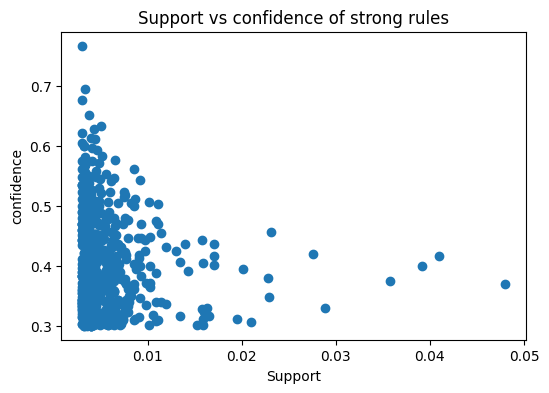

In [41]:
plt.figure(figsize=(6,4))
plt.scatter(strong_rules['support'],strong_rules['confidence'])
plt.xlabel('Support')
plt.ylabel('confidence')
plt.title('Support vs confidence of strong rules')
plt.show()

as you can see most strong rules occur in small fraction of transactions.
this scatterplot illustrate a clear tradeoff between support and confidence. most strong associations rules have low support but moderate to high confidence, indicating that niche purchasing items are more reliable.rules with higher support generally exhibit moderate confidence, suggesting broader but less specific customer behaviour.

# Confidence
in this assignment, association rule was applied to a retail transcation dataset using the apriori algorithm. after preprocessing and transaction encoding , frequent itemsets and association rules were generated. several strong rules were also identified with strong confidence and lift. which may indicate meanigfull relationships between certain products.

these discovered association rules can be used for cross selling , product bundling, and shelf placement optimization. for example items such as soup, frozen veggies and mineral water could be placed closer together or promoted as bundled offer. these insights can help retailer improve customer experience and basket values

# interview Questions


1.	What is lift and why is it important in Association rules?
 lift is a reality check for your rules. it tells you if two items are actually related or if they are just bought together by just coincidence. basically lift measures the strength of an association between two items , compared to their individual base probabilities.. it is important because a high confidence score can be misleading.
 
2.	What is support and Confidence. How do you calculate them?
    support is a popularity contest it asks how often these items appear in the dataset. while confidence is the probability score, it asks if someone buys items A , how sure am i that they will also buy item B.
    
3.	What are some limitations or challenges of Association rules mining?
    a standard dataset can generate millions of rules most of them almost 90 percent are obvious and useless. it takes a human expert to filter out the interesting ones. As the number of unique items increases so does the number of possible combinations, apriori algorithm is too slow for such large datasets which may result in crashinng of computer memory. the algo only looks at 1's and 0's . it doesnt know if a customer bought 1 burger or 60 burgers. which makes it harder to measure financial impact.